# **REGRESION LOGISTICA BINARIA (CLASIFICACION)**

En este modelo se busca predecir la probabilidad de que un cliente pagara el credito el siguiente mes.

0: El cliente no cayó en default (pagó el crédito a tiempo).

1: El cliente cayó en default (no pagó el crédito a tiempo).

Haremos uso de las siguientes columnas:

Edad (age): Da un contexto demográfico básico. La edad puede correlacionar con estabilidad financiera.

Historial de pagos (pay0 a pay6): Es la señal más fuerte para predecir comportamiento futuro. Si alguien tuvo retrasos antes, hay más probabilidad de que vuelva a retrasarse o incluso caer en default.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Importamos las librerias necesarias

In [ ]:
import os

import numpy as np

from matplotlib import pyplot

from scipy import optimize

%matplotlib inline

# **Preparamos los datos**
Cargamos el dataset

In [ ]:
import pandas as pd
df= pd.read_csv('/content/drive/MyDrive/Inteligencia Artificial I/Datasets Trabajos/UCI_Credit_Card.csv')
print(df)

          ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  \
0          1    20000.0    2          2         1   24      2      2     -1   
1          2   120000.0    2          2         2   26     -1      2      0   
2          3    90000.0    2          2         2   34      0      0      0   
3          4    50000.0    2          2         1   37      0      0      0   
4          5    50000.0    1          2         1   57     -1      0     -1   
...      ...        ...  ...        ...       ...  ...    ...    ...    ...   
29995  29996   220000.0    1          3         1   39      0      0      0   
29996  29997   150000.0    1          3         2   43     -1     -1     -1   
29997  29998    30000.0    1          2         2   37      4      3      2   
29998  29999    80000.0    1          3         1   41      1     -1      0   
29999  30000    50000.0    1          2         1   46      0      0      0   

       PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  B

Preparamos el dataset

In [ ]:
print('INFORMACION DE TIPO DE DATOS')
df.info()
print('\nDATOS VACIOS')
print(pd.isnull(df).sum())

INFORMACION DE TIPO DE DATOS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         30000 non-null  int64  
 1   LIMIT_BAL  30000 non-null  float64
 2   SEX        30000 non-null  int64  
 3   EDUCATION  30000 non-null  int64  
 4   MARRIAGE   30000 non-null  int64  
 5   AGE        30000 non-null  int64  
 6   PAY_0      30000 non-null  int64  
 7   PAY_2      30000 non-null  int64  
 8   PAY_3      30000 non-null  int64  
 9   PAY_4      30000 non-null  int64  
 10  PAY_5      30000 non-null  int64  
 11  PAY_6      30000 non-null  int64  
 12  BILL_AMT1  30000 non-null  float64
 13  BILL_AMT2  30000 non-null  float64
 14  BILL_AMT3  30000 non-null  float64
 15  BILL_AMT4  30000 non-null  float64
 16  BILL_AMT5  30000 non-null  float64
 17  BILL_AMT6  30000 non-null  float64
 18  PAY_AMT1   30000 non-null  float64
 19  PAY_AMT2   30000 

Como se puede observar las columnas que usaremos ya estan en un formato de int64 y no presentan valores nulos. Por lo que descartamos el resto de columnas.

In [ ]:
df.drop(['ID'], axis=1, inplace=True)
df.drop(['LIMIT_BAL'], axis=1, inplace=True)
df.drop(['SEX'], axis=1, inplace=True)
df.drop(['EDUCATION'], axis=1, inplace=True)
df.drop(['MARRIAGE'], axis=1, inplace=True)
df.drop(['BILL_AMT1'], axis=1, inplace=True)
df.drop(['BILL_AMT2'], axis=1, inplace=True)
df.drop(['BILL_AMT3'], axis=1, inplace=True)
df.drop(['BILL_AMT4'], axis=1, inplace=True)
df.drop(['BILL_AMT5'], axis=1, inplace=True)
df.drop(['BILL_AMT6'], axis=1, inplace=True)
df.drop(['PAY_AMT1'], axis=1, inplace=True)
df.drop(['PAY_AMT2'], axis=1, inplace=True)
df.drop(['PAY_AMT3'], axis=1, inplace=True)
df.drop(['PAY_AMT4'], axis=1, inplace=True)
df.drop(['PAY_AMT5'], axis=1, inplace=True)
df.drop(['PAY_AMT6'], axis=1, inplace=True)

print(df)

       AGE  PAY_0  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  target
0       24      2      2     -1     -1     -2     -2       1
1       26     -1      2      0      0      0      2       1
2       34      0      0      0      0      0      0       0
3       37      0      0      0      0      0      0       0
4       57     -1      0     -1      0      0      0       0
...    ...    ...    ...    ...    ...    ...    ...     ...
29995   39      0      0      0      0      0      0       0
29996   43     -1     -1     -1     -1      0      0       0
29997   37      4      3      2     -1      0      0       1
29998   41      1     -1      0      0      0     -1       1
29999   46      0      0      0      0      0      0       1

[30000 rows x 8 columns]


Ahora asignamos las columnas a las variables

In [ ]:
X = df[['AGE','PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']].copy()
y = df['target'].copy()

El valor original de las variables PAY_0-6 (-1=pago a tiempo, 1=retraso de pago de un mes, 2=retraso de pago de dos
meses, … 8=retraso de pago de ocho meses, 9=retraso de pago de nueve meses o más) se simplificaran las múltiples a una escala binaria (pago normal vs. retraso), para una mejor comprension:


In [ ]:
def convert_pay_status(status):
    if status == -1:
        return 0
    else:
        return 1

In [ ]:
pay_columns = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
for col in pay_columns:
    X[col] = X[col].apply(convert_pay_status)

print("Variables 'PAY_' después de la conversión a 0 y 1:")
print(X)
print(y)

Variables 'PAY_' después de la conversión a 0 y 1:
       AGE  PAY_0  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6
0       24      1      1      0      0      1      1
1       26      0      1      1      1      1      1
2       34      1      1      1      1      1      1
3       37      1      1      1      1      1      1
4       57      0      1      0      1      1      1
...    ...    ...    ...    ...    ...    ...    ...
29995   39      1      1      1      1      1      1
29996   43      0      0      0      0      1      1
29997   37      1      1      1      0      1      1
29998   41      1      0      1      1      1      0
29999   46      1      1      1      1      1      1

[30000 rows x 7 columns]
0        1
1        1
2        0
3        0
4        0
        ..
29995    0
29996    0
29997    1
29998    1
29999    1
Name: target, Length: 30000, dtype: int64


# **Visualizacion de Datos**

En este caso graficaremos en el eje de las x las edades y en el eje de las y las PAY_0.

Eje X: Representa la Edad del cliente.

Eje Y: Representa el Estado de Pago del cliente. Como preprocesamos la variable, solo tiene dos valores:

0: Indica que el cliente realizó un pago normal o a tiempo.

1: Indica que el cliente tuvo un retraso en el pago.

Marcadores: La forma y el color de los puntos en el gráfico indican si el cliente incumplió (target = 1, representado con estrellas) o no incumplió (target = 0, representado con círculos).

In [ ]:
X_plot = X[['AGE', 'PAY_0']].values
y_plot = y.values

In [ ]:
def plotData(X, y):

    fig = pyplot.figure()

    pos = y == 1
    neg = y == 0

    pyplot.plot(X[pos, 0], X[pos, 1], 'k*', lw=2, ms=10, label="Incumplimiento")
    pyplot.plot(X[neg, 0], X[neg, 1], 'ko', mfc='y', ms=8, mec='k', mew=1, label="No Incumplimiento")


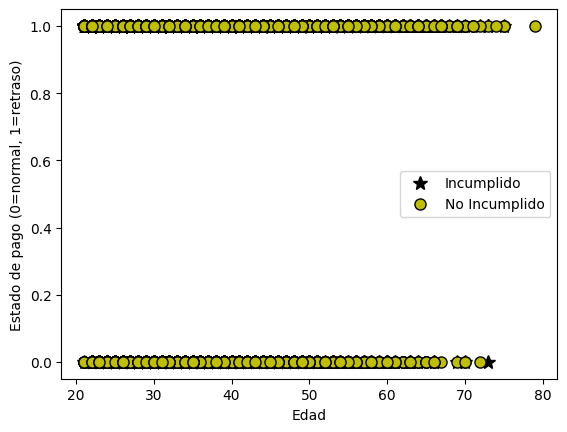

In [ ]:
plotData(X_plot, y_plot)
pyplot.xlabel('Edad')
pyplot.ylabel('Estado de pago (0=normal, 1=retraso)')
pyplot.legend(['Incumplido', 'No Incumplido'])
pass

# **Division de los datos**

Utilizaremos el 80% de los datos para entrenar y el 20% para probar, para eso usaremos sklearn.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Aplicamos Normalizacion

In [ ]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [ ]:
X_train_norm, mu, sigma = featureNormalize(X_train)

In [ ]:
X_test_norm = (X_test - mu) / sigma
m_test = len(X_test)

In [ ]:
print(X_train)
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_train_norm)

       AGE  PAY_0  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6
21753   24      1      1      1      1      1      1
251     28      1      1      1      1      1      1
22941   44      1      1      0      0      0      0
618     25      1      1      1      1      1      1
17090   25      1      1      1      1      1      1
...    ...    ...    ...    ...    ...    ...    ...
29802   32      1      1      1      1      1      1
5390    37      1      1      1      1      1      1
860     26      1      1      1      1      1      1
15795   25      1      1      1      1      1      1
23654   36      1      1      1      1      1      1

[24000 rows x 7 columns]
Media calculada: AGE      35.494375
PAY_0     0.809500
PAY_2     0.796875
PAY_3     0.800708
PAY_4     0.812000
PAY_5     0.817167
PAY_6     0.808250
dtype: float64
Desviación estandar calculada: AGE      9.234968
PAY_0    0.392695
PAY_2    0.402325
PAY_3    0.399468
PAY_4    0.390712
PAY_5    0.386530
PAY_6    0.393677
dtype: float64
 

# **IMPLEMENTACION**
**Funcion Sigmoidea**

In [ ]:
def sigmoid(z):

    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

**Funcion de Costo y Gradiente**

Agregamos el termino de intercepcion a X.

In [ ]:
X_train_norm = np.concatenate([np.ones((X_train_norm.shape[0], 1)), X_train_norm], axis=1)
X_test_norm = np.concatenate([np.ones((X_test_norm.shape[0], 1)), X_test_norm], axis=1)

In [ ]:
print("\n--- Datos con el término de intercepción ---")
print("Forma de X_train_final:", X_train_norm.shape)
print("Forma de X_test_final:", X_test_norm.shape)
print("Primeras 5 filas del DataFrame de entrenamiento con intercepción:")
print(X_train_norm[:5])


--- Datos con el término de intercepción ---
Forma de X_train_final: (24000, 8)
Forma de X_test_final: (6000, 8)
Primeras 5 filas del DataFrame de entrenamiento con intercepción:
[[ 1.         -1.2446578   0.4851087   0.50487816  0.49889298  0.48117262
   0.47301223  0.48707387]
 [ 1.         -0.81152149  0.4851087   0.50487816  0.49889298  0.48117262
   0.47301223  0.48707387]
 [ 1.          0.92102376  0.4851087   0.50487816 -2.00443789 -2.07825622
  -2.11411025 -2.05307668]
 [ 1.         -1.13637372  0.4851087   0.50487816  0.49889298  0.48117262
   0.47301223  0.48707387]
 [ 1.         -1.13637372  0.4851087   0.50487816  0.49889298  0.48117262
   0.47301223  0.48707387]]


In [ ]:
print(X_test_norm[:5])

[[ 1.         -1.13637372  0.4851087   0.50487816  0.49889298  0.48117262
   0.47301223  0.48707387]
 [ 1.         -1.02808964  0.4851087   0.50487816  0.49889298  0.48117262
   0.47301223  0.48707387]
 [ 1.         -0.37838517  0.4851087   0.50487816  0.49889298  0.48117262
   0.47301223  0.48707387]
 [ 1.          1.46244415  0.4851087   0.50487816  0.49889298  0.48117262
   0.47301223 -2.05307668]
 [ 1.          0.05475114  0.4851087   0.50487816  0.49889298  0.48117262
   0.47301223  0.48707387]]


In [ ]:
def calcularCosto(theta, X, y):
    m = y.size
    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    return J

In [ ]:
def descensoGradiente(theta, X, y, alpha, num_iters):

    m = y.shape[0]


    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

**Entrenar el modelo y visualizar la convergencia del costo**


--- Resultados del entrenamiento ---
Costo final: 0.5265001096852076
Theta calculado por el descenso por el gradiente: [-1.13969578  0.0398874   0.0126373   0.05585801  0.06267519  0.04660128
  0.03823313  0.02991819]


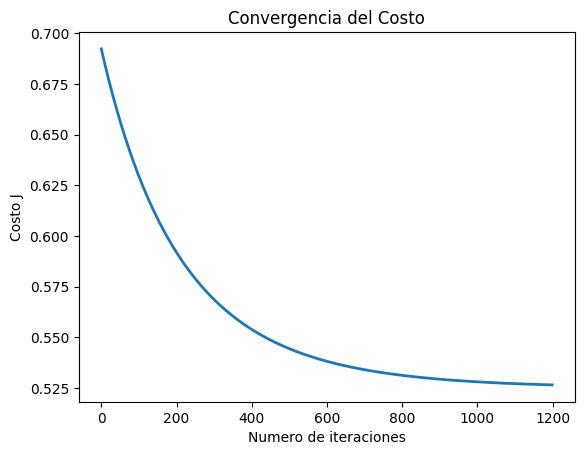

In [ ]:
alpha = 0.01
num_iters = 1200

theta = np.zeros(X_train_norm.shape[1])
theta, J_history = descensoGradiente(theta, X_train_norm, y_train, alpha, num_iters)

pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Costo')

print('\n--- Resultados del entrenamiento ---')
print('Costo final:', J_history[-1])
print('Theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

# **Test de Validacion**

In [ ]:
y_predicha = []

for i in X_test_norm:
  y_predicha.append(sigmoid(np.dot(i, theta)))

y_predicha = np.array(y_predicha)


# Usando el umbral donde todo valor que sea >= 0.5 sera 1 o al contrario es 0
y_umbral = (y_predicha >= 0.5).astype(int)

Convertimos los datos de prediccion a un data frame

In [ ]:
df_pred = pd.DataFrame(y_predicha*100, columns = ['Probabilidad de incumplimiento %'])

Convertimos los datos de prueba a un dataframe para mostrar

In [ ]:
X_test_display = pd.DataFrame(X_test, columns=X.columns)
y_test_display = pd.DataFrame(y_test.values, columns=['Valores Reales'])

Mostramos los resultados en una sola tabla

In [ ]:
df_resultado = pd.concat([X_test_display.reset_index(drop=True), y_test_display, df_pred], axis=1)
pd.set_option('display.max_columns', None)
print(df_resultado.head(200))

     AGE  PAY_0  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  Valores Reales  \
0     25      1      1      1      1      1      1               0   
1     26      1      1      1      1      1      1               0   
2     32      1      1      1      1      1      1               0   
3     49      1      1      1      1      1      0               0   
4     36      1      1      1      1      1      1               1   
..   ...    ...    ...    ...    ...    ...    ...             ...   
195   35      1      1      1      1      1      1               1   
196   39      1      1      1      1      1      1               0   
197   27      1      1      1      1      1      1               0   
198   25      1      1      1      1      1      1               0   
199   33      0      0      0      0      0      0               0   

     Probabilidad de incumplimiento %  
0                           25.648052  
1                           25.730505  
2                           26.228845  

Mostramos la precision de entrenamiento
Usamos y_test.values.ravel() para asegurarnos de que el formato sea el correcto para la comparación

In [ ]:
print("\nPrecisión de entrenamiento: {:.2f} % ".format(np.mean(y_umbral == y_test.values.ravel()) * 100))


Precisión de entrenamiento: 78.12 % 


# **Realizamos una prediccion.**

Por ejemplo: Edad=40, PAY_0=0 (normal), PAY_2=1 (retraso), etc.

In [ ]:
nuevo_cliente = np.array([40, 0, 1, 1, 0, 0, 0])

Normalizamos los datos

In [ ]:
nuevo_cliente_norm = (nuevo_cliente - mu.values) / sigma.values
nuevo_cliente_final = np.concatenate([[1], nuevo_cliente_norm])

Calculamos el sigmoideo

In [ ]:
probabilidad_incumplimiento = sigmoid(np.dot(nuevo_cliente_final, theta))

Prediccion Final

In [ ]:
print('\n--- Predicción de ejemplo ---')
print(f'Un cliente con las características [Edad: 40, PAY_0: 0, PAY_2: 1, PAY_3: 1, PAY_4: 0, PAY_5: 0, PAY_6: 0]')
print(f'Tiene una probabilidad de incumplir de: {probabilidad_incumplimiento:.4f}')


--- Predicción de ejemplo ---
Un cliente con las características [Edad: 40, PAY_0: 0, PAY_2: 1, PAY_3: 1, PAY_4: 0, PAY_5: 0, PAY_6: 0]
Tiene una probabilidad de incumplir de: 0.2098
